# Étape 2 — Analyse des sentiments des conversations

## Notebook annoté

Ce notebook implémente un **classificateur de sentiments** sur des textes liés à la santé mentale, en suivant deux approches complémentaires :
- **Méthode supervisée** : Naive Bayes
- **Méthode non-supervisée** : K-Means

Le corpus d'entraînement utilisé est le dataset *Sentiment Analysis for Mental Health* (`Combined Data.csv`) disponible sur Kaggle.

---

## 1. Initialisation

Cette cellule importe l'ensemble des bibliothèques nécessaires au notebook :

| Bibliothèque | Rôle |
|---|---|
| `numpy`, `pandas` | Manipulation de données et tableaux numériques |
| `matplotlib`, `seaborn` | Visualisation (graphiques, camemberts) |
| `re` | Expressions régulières pour le nettoyage du texte |
| `WordCloud` | Génération de nuages de mots |
| `Counter` | Comptage de fréquences d'éléments |
| `sklearn` | Modèles ML, vectorisation, métriques d'évaluation |
| `nltk` | Traitement du langage naturel (tokenisation, stop-words) |

In [1]:
# importing libraries and packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import re
from wordcloud import WordCloud
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, confusion_matrix,
                             mean_squared_error, r2_score,
                             classification_report, ConfusionMatrixDisplay)
from sklearn.preprocessing import LabelEncoder

import nltk 
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

import pickle

### 1.1 Chargement des données

Chargement du fichier `Combined Data.csv` dans un DataFrame pandas. Le paramètre `index_col=0` indique que la première colonne du CSV est l'index des lignes (et non une colonne de données à part entière). `df.head()` affiche les 5 premières lignes pour vérifier que le chargement s'est bien passé.

In [2]:
df=pd.read_csv("../../data/combined_data.csv",index_col=0)
df.head()

,statement,status
0,oh my gosh,Anxiety
1,"trouble sleeping, confused mind, restless hear...",Anxiety
2,"All wrong, back off dear, forward doubt. Stay ...",Anxiety
3,I've shifted my focus to something else but I'...,Anxiety
4,"I'm restless and restless, it's been a month n...",Anxiety


### 1.2 Mélange des données

Le dataset est **mélangé aléatoirement** (`sample(frac=1)`) avant tout traitement. Cela évite un biais si les données sont triées par ordre (ex : toutes les lignes d'une même classe regroupées). `random_state=42` garantit la **reproductibilité** : le même ordre sera obtenu à chaque exécution. `reset_index(drop=True)` remet les indices à 0, 1, 2… après le mélange.

In [3]:
# shuffle the rows, reset the indices
df = df.sample(frac = 1 ,random_state=42).reset_index(drop = True)
df

,statement,status
0,Just as the the title says. I feel like one is...,Depression
1,a blackened sky encroached tugging behind it m...,Depression
2,"It gives you insomnia, which in turn makes you...",Depression
3,"Hello all, I'm a new submitter to this channel...",Normal
4,Thank God the CB is over for Eid,Normal
...,...,...
53038,"I used to be a very confident, cheerful person...",Depression
53039,spanx except i missed last week s lee and now ...,Normal
53040,tl dr have been abused mentally and physically...,Depression
53041,do i sell the tutorial again?,Normal


### 1.3 Distribution des classes

`value_counts()` compte le nombre d'occurrences de chaque valeur unique dans la colonne `status` (les étiquettes de sentiment). Cette étape permet de vérifier si le dataset est **équilibré** ou non — un déséquilibre important entre classes peut impacter les performances des modèles.

In [4]:
# Count the occurrences of each status
label_counts = df['status'].value_counts()
print(label_counts)

status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Name: count, dtype: int64


## 1.4 Visualisation de la distribution (camembert)

Ce graphique en camembert représente visuellement la **distribution des classes** calculée à l'étape précédente. `autopct='%1.1f%%'` affiche le pourcentage de chaque classe avec une décimale. La palette `pastel` de seaborn donne des couleurs douces et distinctes.

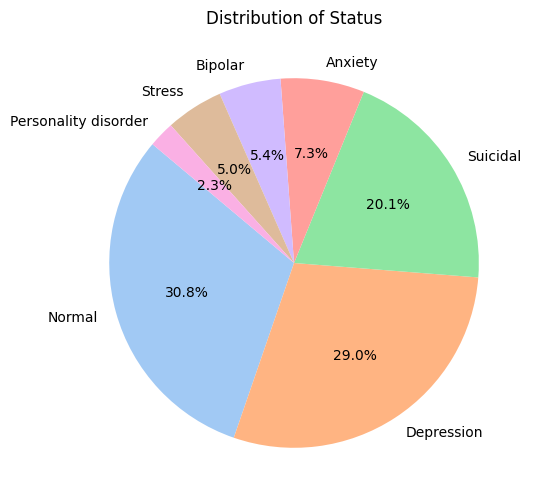

In [5]:
# Plot the pie chart
plt.figure(figsize=(6, 6))
plt.pie(label_counts, labels=label_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette('pastel'))
plt.title('Distribution of Status');

---
## 2. Nettoyage des données
### 2.1. Détection des valeurs manquantes

`isnull().sum()` compte le nombre de valeurs `NaN` (manquantes) dans chaque colonne. C'est une étape systématique de **contrôle qualité** : des valeurs manquantes dans la colonne `statement` provoqueraient des erreurs lors du nettoyage ou de la vectorisation.

In [6]:
# Missing values
df.isnull().sum()

statement    362
status         0
dtype: int64

### 2.2 Suppression des lignes vides

`dropna(axis=0)` supprime toutes les lignes contenant au moins une valeur manquante. Le paramètre `inplace=True` modifie directement le DataFrame sans créer une copie. Cette étape fait suite à la détection précédente.

In [7]:
# Drop rows with missing values
df.dropna(axis=0, inplace = True)
df.describe()

,statement,status
count,52681,52681
unique,51073,7
top,what do you mean?,Normal
freq,22,16343


### 2.3. Détection des étiquettes conflictuelles

Certains énoncés (`statement`) peuvent apparaître plusieurs fois dans le dataset avec des étiquettes (`status`) différentes — ce qui est contradictoire pour l'apprentissage. Cette cellule identifie ces cas en comptant le nombre de statuts distincts par énoncé. Si `nunique() != 1`, l'énoncé a plusieurs labels incompatibles.

In [8]:
# Count unique statuses for each statement
duplicate_labels = df.groupby('statement')['status'].nunique()

# Filter statements with more than one unique status
conflicting_statements = duplicate_labels[duplicate_labels != 1]

# Display problematic statements
print(f"Nombre de déclarations en conflit : {len(conflicting_statements)}")

Nombre de déclarations en conflit : 18


### 2.4 Suppression des étiquettes conflictuelles

On conserve uniquement les lignes dont l'énoncé possède **un seul statut cohérent** (`nunique() == 1`). Le `transform('nunique')` propage la valeur calculée par groupe à chaque ligne individuelle, ce qui permet le filtrage. `df.shape` est affiché pour confirmer la taille du dataset après nettoyage.

In [9]:
# Remove rows with confilicting labels, only keep statements that have a single consistent status
df = df[df.groupby('statement')['status'].transform('nunique') == 1]

print(df.shape)  # Check new dataset size

(52632, 2)


### 2.5. Nettoyage du texte (`cleaner`)

Cette fonction applique plusieurs **règles de nettoyage** via des expressions régulières :

| Règle | Exemple |
|---|---|
| Suppression des mentions `@utilisateur` | `@john` → supprimé |
| Suppression des URLs | `https://...` → supprimé |
| Suppression du HTML | `<br>`, `<b>` → supprimé |
| Détection des émoticônes textuels | `:)`, `;-P` → conservés en fin |
| Mise en minuscules + suppression des non-mots | `Hello!` → `hello` |

Les émoticônes sont extraits avant la suppression des non-mots, puis réajoutés à la fin du texte nettoyé.

In [10]:
# Defining a text cleaner
import re
def cleaner(text):
    text = re.sub(r'\s*@\w+', '', text)                            # remove words starting with @ 
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)            # remove URLs 
    text = re.sub(r'<[^>]*>', '', text)                            # remove all of the HTML markup
    #text = re.sub(r'\b\w\b', '', text)                             # remove single letters, I, a, ...
    emoticons = re.findall(r'(?::|;|=)(?:-)?(?:\)|\(|D|P)', text)  # find emoticons (emoji)
    text = (re.sub(r'[\W]+', ' ', text.lower()) + ' '.join(emoticons).replace('-', '')) 
    #  replace any non_word with space, lowercase words, add emojis at the end
    return text

### 2.6. Application du nettoyage

La fonction `cleaner` est appliquée à chaque ligne de la colonne `statement` via `.apply()`. `df.loc[:, 'statement']` est utilisé (plutôt que `df['statement']`) pour éviter un `SettingWithCopyWarning` de pandas lors de la modification en place. Le nombre de lignes restantes est affiché en sortie.

> **Note** : le bloc de détection de langue (`is_english`) est commenté. Il permettrait de ne conserver que les textes en anglais, mais alourdit le traitement. À réactiver si le corpus contient des textes multilingues.

In [11]:
# Cleaning the text
from langdetect import detect
from langdetect import DetectorFactory
DetectorFactory.seed = 42
df.loc[:, 'statement'] = df['statement'].apply(cleaner)
#def is_english(text):
 #   try:
  #      return detect(str(text)) == 'en'
   # except:
    #    return False  # si détection échoue on supprime la ligne
print(f"Après filtres : {df.shape[0]} lignes")
#df['statement'].apply(is_english)
#print(f"Après filtres : {df.shape[0]} lignes")
#only english text in base documents

Après filtres : 52632 lignes


### 2.7 Vérification d'un exemple nettoyé

Affiche le contenu de la ligne d'index 10 après nettoyage, pour vérifier visuellement que la fonction `cleaner` produit bien le résultat attendu (minuscules, sans ponctuation ni URL).

In [12]:
df['statement'][10]

'so i m sure all of you who live with anxiety do have your good day like the bad crippling anxiety come in wave which it doe for me when it s bad my anxiety is looking for any reason to latch it s self onto and make me believe that whatever the reason is that s what make me feel like shit when i have my good day and that thought or issue come to mind i m unfazed it s really fuckn annoying and i feel like it could make me make decision that i will for sure regret why is the brain so damn powerful and why do i have to live with this year of always feeling like shit it ha ruined my quality of life i am very grateful for my family and friend and i am grateful that i ve always had a good life but man i think of all the family trip event party anything fun ruined by my anxiety and sickness that come with it i feel for everyone that ha to go through this i m sorry guy and i hope one day we can be truly happy'

### 2.8 Séparation features / cible

On sépare le DataFrame en deux variables :
- `X` : les **features** (les énoncés textuels nettoyés, colonne `statement`)
- `y` : la **cible** (les étiquettes de sentiment, colonne `status`)

C'est la convention standard en scikit-learn avant tout découpage ou entraînement.

In [13]:
# Assigning features and target
X = df['statement']
y = df['status']

---
## 3. Entrainement du modèle
### 3.1 Découpage Train / Validation / Test

Mais alors pourquoi séparer les donnée en 3 et non 2 ?
En effet, il est courant de diviser les données en trois ensembles :
- **Ensemble d'entraînement (Train)** : utilisé pour entraîner le modèle.
- **Ensemble de validation (Validation)** : utilisé pour ajuster les hyperparamètres du modèle et éviter le surapprentissage (overfitting).
- **Ensemble de test (Test)** : utilisé pour évaluer la performance finale du modèle sur des données qu'il n'a jamais vues auparavant.
Cela permet d'avoir une évaluation plus fiable de la performance du modèle, car le test est effectué sur des données totalement indépendantes de celles utilisées pour l'entraînement et la validation.

Le paramètre `stratify=y` garantit que la **proportion de chaque classe** est identique dans les trois ensembles — indispensable en cas de déséquilibre des classes. `random_state=42` assure la reproductibilité.

In [14]:
# First split -> 60% train, 40% temp (validation + test)
# Second split -> 20% validation, 20% test (from the 40% temp)

X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.4, random_state=42, stratify=y)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

print(f"Train : {X_train.shape[0]} | Val : {X_val.shape[0]} | Test : {X_test.shape[0]}")

Train : 31579 | Val : 10526 | Test : 10527


### 3.2 Vérification de la distribution des classes

On s'assure que `stratify` a bien préservé les proportions dans les 3 ensembles.

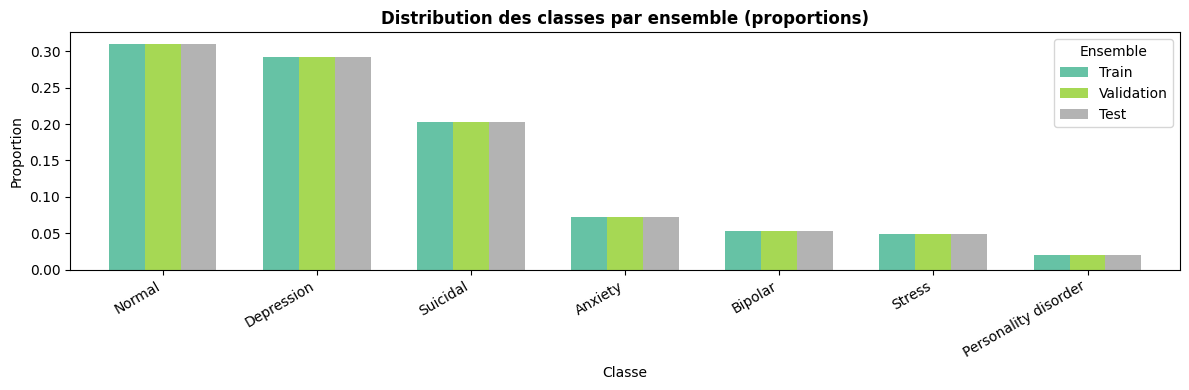

In [15]:
dist = pd.DataFrame({
    'Train'      : y_train.value_counts(normalize=True),
    'Validation' : y_val.value_counts(normalize=True),
    'Test'       : y_test.value_counts(normalize=True),
}).fillna(0)

ax = dist.plot(kind='bar', figsize=(12, 4), colormap='Set2', width=0.7)
ax.set_title('Distribution des classes par ensemble (proportions)', fontweight='bold')
ax.set_xlabel('Classe')
ax.set_ylabel('Proportion')
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right')
ax.legend(title='Ensemble')
plt.tight_layout()
plt.show()

### 3.3 Préambule tokenisation

- **Punkt** : modèle pré-entraîné de NLTK qui segmente le texte en mots tout en gérant les abréviations et la ponctuation (.,!,?).
Il gère aussi les abréviations (ex. `Dr.Smith` ne sera pas séparé en `Dr` puis `.` puis `Smith`)
- **Stop words** : mots très fréquents sans valeur sémantique (`the`, `is`, `and`…) qui sont retirés pour réduire le bruit.
- **Porter Stemmer** : algorithme qui réduit chaque mot à sa racine (`running` → `run`, `people` → `peopl`). Les formes produites ne sont pas toujours des mots réels, c'est un compromis connu.

#### 3.3.1 Fonction de tokenisation

La fonction `simple_tokenizer` applique en séquence :
1. **Tokenisation** : découpe la chaîne en liste de mots avec `word_tokenize`
2. **Filtrage des stop-words** : retire les mots sans valeur sémantique
3. **Stemming** : réduit chaque mot à sa racine avec le Porter Stemmer

L'exemple en fin de cellule (`"i.e., running faster..."`) permet de tester le comportement sur une phrase contenant une abréviation et une majuscule.

In [16]:
# Splitting text documents into tokens
import nltk 
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

In [17]:
# Download required NLTK data
nltk.download('punkt_tab')      # For punctuations used in word_tokenize 
nltk.download('stopwords')      # For stopword list

[nltk_data] Downloading package punkt_tab to /home/logan/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to /home/logan/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [18]:
def simple_tokenizer(text):
    stop_words = set(stopwords.words('english'))    # Define stopwords (English)
    stemmer = PorterStemmer()                       # Initialize the stemmer
    tokens = word_tokenize(text)                    # Tokenize the text   
    filtered_tokens = [word for word in tokens if word.lower() not in stop_words] # Remove stopwords   
    stemmed_tokens = [stemmer.stem(word) for word in filtered_tokens]             # Apply stemming
    return stemmed_tokens

# Example Usage
text = "i.e., running faster makes you stronger Mrs. Williams!"
print(simple_tokenizer(text))

['i.e.', ',', 'run', 'faster', 'make', 'stronger', 'mrs.', 'william', '!']


#### 3.3.2 Application de la tokenisation

La fonction `simple_tokenizer` est appliquée à chaque énoncé des ensembles train et test via `.apply()`. Chaque texte est ainsi transformé en une **liste de tokens** (racines de mots filtrés). Ces listes seront ensuite converties en vecteurs numériques par les vectoriseurs.

> **Attention**: Le temp d'exécution estimé peut aller de 1min à 2min30 !

In [19]:
# Application of tokenizer
X_train_tokens = X_train.apply(simple_tokenizer)
X_val_tokens   = X_val.apply(simple_tokenizer)
X_test_tokens  = X_test.apply(simple_tokenizer)

#### 3.3.3 Tokenisation du dataset complet

La tokenisation est également appliquée sur `X` entier (train + test confondus). Cette version `X_full` sera utilisée plus tard pour la vectorisation TF-IDF complète, notamment dans le contexte du déploiement sur le dataset principal (`train.csv`).

In [20]:
X_full=X.apply(simple_tokenizer)

#### 3.3.4. Aperçu des tokens

Affiche les 5 premières lignes tokenisées. Chaque cellule contient une liste de racines de mots. On peut y observer les effets du Porter Stemmer : `people` → `peopl`, `jealous` → `jealou`, etc. C'est le comportement attendu (voir discussion dans le notebook).

In [21]:
# View a few tokenised statements
X_train_tokens.head()

22977                                       [lemau, right]
22034    [think, peopl, see, think, worst, hate, presen...
5223     [stress, leav, anyon, ever, success, take, fml...
10113    [safe, sane, sober, check, good, support, netw...
22176    [well, coupl, month, recent, got, hit, anoth, ...
Name: statement, dtype: object

---
### 3.4. Bag-of-Words (BoW)

#### 3.4.1 Vectorisation BoW

Le **Bag-of-Words** crée une matrice où chaque ligne est un document et chaque colonne est un mot du vocabulaire. La valeur d'une cellule est le **nombre d'occurrences** du mot dans le document.

- `fit_transform` sur le train : construit le vocabulaire **et** transforme les données
- `transform` sur le test : applique le **même vocabulaire** sans le reconstruire (règle fondamentale pour éviter le data leakage)

Les tokens (listes) sont reconvertis en chaînes (`' '.join(x)`) car `CountVectorizer` attend des strings.

In [22]:
from sklearn.feature_extraction.text import CountVectorizer

# Initializing a vectoriser
bow_vectorizer = CountVectorizer()

# Fitting to the bow-vectorizer — sur le train uniquement
X_train_bow = bow_vectorizer.fit_transform(X_train_tokens.apply(lambda x: ' '.join(x)))
X_val_bow   = bow_vectorizer.transform(X_val_tokens.apply(lambda x: ' '.join(x)))
X_test_bow  = bow_vectorizer.transform(X_test_tokens.apply(lambda x: ' '.join(x)))

#### 3.4.2. Aperçu du vocabulaire BoW

Affiche un extrait du vocabulaire appris par le `CountVectorizer` (tokens de rang 2000 à 2080). Permet de vérifier que les termes stockés sont bien des racines issues du stemming, et non des mots bruts.

In [23]:
# Show some of the vocabulary words
bow_vectorizer.get_feature_names_out()[2000:2080]  

array(['alamin', 'alan', 'alanin', 'alarm', 'alarmingli', 'alaska',
       'albanian', 'albeit', 'albert', 'alberta', 'albertson', 'album',
       'albumin', 'alc', 'alcahol', 'alcançar', 'alcapa', 'alchemist',
       'alchi', 'alchoh', 'alchohol', 'alchool', 'alco', 'alcohol',
       'alcoholi', 'alcol', 'alcoohol', 'alcool', 'ale', 'aleay', 'alec',
       'alejandralei', 'alement', 'alergi', 'alert', 'alessandrod',
       'alesso', 'alev', 'alevel', 'alex', 'alexa', 'alexandernl',
       'alexfost', 'alexlobaloba', 'alexrussin', 'alfredo', 'alg',
       'algebra', 'algn', 'algo', 'algonquin', 'algorithm', 'alguna',
       'alguno', 'alguém', 'alhaji', 'alhamdulilah', 'alhamdulillaaah',
       'alhamdulillah', 'alhasani', 'alhogol', 'ali', 'alia', 'alic',
       'aliceeu', 'aliceverheij', 'alielayu', 'alien', 'align', 'alik',
       'alimoni', 'alimwomba', 'alissa', 'alist', 'alittl', 'aliv',
       'alivei', 'aliveim', 'alivesomewher', 'alivesorri'], dtype=object)

#### 3.4.3 Dimensions de la matrice BoW

`X_train_bow.shape` retourne `(n_documents, n_features)` — le nombre de documents d'entraînement et la taille du vocabulaire. La matrice est **creuse** (sparse) : la plupart des cellules valent 0 car chaque document n'utilise qu'une infime fraction du vocabulaire total.

In [24]:
# View the dimensions of the BoW matrix and a small portion of its data
print(X_train_bow.shape)  # (num_samples: documents, num_features: unique tokens)
print(X_train_bow[:5])    # Shows first 5 rows (sparse format: only non-zero elements)

(31579, 31180)
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 110 stored elements and shape (5, 31180)>
  Coords	Values
  (0, 16090)	1
  (0, 23209)	1
  (1, 27344)	2
  (1, 20699)	1
  (1, 24119)	1
  (1, 30466)	1
  (1, 12582)	1
  (1, 21596)	1
  (1, 9428)	1
  (1, 13675)	1
  (1, 9870)	1
  (1, 16953)	1
  (1, 29051)	1
  (2, 26095)	2
  (2, 16035)	3
  (2, 2620)	1
  (2, 9716)	1
  (2, 26256)	1
  (2, 26764)	1
  (2, 10756)	1
  (2, 21735)	1
  (2, 16272)	1
  (2, 23089)	1
  (2, 21637)	1
  (2, 9269)	1
  :	:
  (4, 27881)	1
  (4, 29960)	1
  (4, 6737)	1
  (4, 18137)	1
  (4, 22576)	1
  (4, 11922)	1
  (4, 13055)	1
  (4, 2496)	1
  (4, 29833)	1
  (4, 7675)	1
  (4, 10563)	1
  (4, 1411)	1
  (4, 20787)	1
  (4, 13532)	2
  (4, 9098)	1
  (4, 9343)	1
  (4, 5252)	2
  (4, 9391)	1
  (4, 27620)	1
  (4, 12826)	1
  (4, 18256)	1
  (4, 3628)	1
  (4, 18831)	1
  (4, 22510)	1
  (4, 26140)	1


### 3.5 TF-IDF
#### 3.5.1 Vectorisation TF-IDF

Le **TF-IDF** (Term Frequency - Inverse Document Frequency) améliore le BoW en pondérant les mots : un mot fréquent dans un document mais rare dans le corpus global reçoit un score élevé, et inversement.

Paramètres utilisés :
- `ngram_range=(1, 2)` : prend en compte les **unigrammes** (mots seuls) et les **bigrammes** (paires de mots consécutifs)
- `max_df=0.8` : ignore les mots présents dans plus de 80% des documents (trop communs)
- `min_df=5` : ignore les mots présents dans moins de 5 documents (trop rares)

Même logique que BoW : `fit_transform` sur train uniquement, `transform` sur test et full.

> Cette section est commenté car une version bien plus performante est implémenté en dessous

In [25]:
# from sklearn.feature_extraction.text import TfidfVectorizer

# # Define TfidfVectorizer with n-gram range
# tfidf_vectorizer = TfidfVectorizer(ngram_range=(1, 2), max_df=0.8, min_df=5)

# # Apply TfidfVectorizer — fit sur le train uniquement
# X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_tokens.apply(lambda x: ' '.join(x)))
# X_val_tfidf   = tfidf_vectorizer.transform(X_val_tokens.apply(lambda x: ' '.join(x)))
# X_test_tfidf  = tfidf_vectorizer.transform(X_test_tokens.apply(lambda x: ' '.join(x)))
# x_full_tfidf  = tfidf_vectorizer.transform(X_full.apply(lambda x: ' '.join(x)))

#### **Version bien plus performante**

La version d'au dessus est tout à fait fonctionnelle, mais peut être grandement amélioré:

- `ngram_range=(1,3)` ajoute en plus de bigrammes les trigrammes
- `max_features=50000` limite le vocabulaire aux 50k features les plus utiles
- `sublinear_tf=True` $log(tf)$ au lieu de tf — réduit l'impact des mots très fréquents
- `min_df=2` ignore les mots apparaissant dans moins de 2 documents
- `max_df=0.95` ignore les mots apparaissant dans plus de 95% des documents

> `sublinear_tf=True` est le plus impactant des deux — il atténue encore plus l'effet des mots très fréquents comme "*feel*" ou "*think*" qui saturent le corpus sans distinguer les classes.

In [26]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 3),      # ajouter les trigrammes en plus des bigrammes
    max_features=50000,      # limiter le vocabulaire aux 50k features les plus utiles
    sublinear_tf=True,       # log(tf) au lieu de tf — réduit l'impact des mots très fréquents
    min_df=2,                # ignorer les mots apparaissant dans moins de 2 documents
    max_df=0.95              # ignorer les mots apparaissant dans plus de 95% des documents
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train_tokens.apply(lambda x: ' '.join(x)))
X_val_tfidf   = tfidf_vectorizer.transform(X_val_tokens.apply(lambda x: ' '.join(x)))
X_test_tfidf  = tfidf_vectorizer.transform(X_test_tokens.apply(lambda x: ' '.join(x)))
x_full_tfidf  = tfidf_vectorizer.transform(X_full.apply(lambda x: ' '.join(x)))

### 3.5.3 Sauvegarde du vectoriseur TF-IDF

On sauvegarde le vectoriseur **après le ** sur le train, au même titre que les modèles. 
Il est indispensable pour vectoriser de nouvelles phrases lors de la prédiction en production — 
sans lui, le modèle LR ne peut pas transformer le texte en entrée.

In [27]:
# Sauvegarde du vectoriseur TF-IDF
# À exécuter juste après le fit — nécessaire pour l'application de prédiction
with open('tfidf_vectorizer.pkl', 'wb') as f:
    pickle.dump(tfidf_vectorizer, f)

print("  tfidf_vectorizer.pkl sauvegardé !")

  tfidf_vectorizer.pkl sauvegardé !


#### 3.5.2 Aperçu des features TF-IDF

Affiche un extrait des features apprises par le `TfidfVectorizer`. On peut y observer des **bigrammes** (ex: `feel anxious`, `mental health`) en plus des unigrammes, ce qui enrichit la représentation sémantique par rapport au BoW simple.

In [28]:
# View Feature Names (Words or N-grams)
print(tfidf_vectorizer.get_feature_names_out()[20100:20150])

['help hope' 'help howev' 'help hurt' 'help husband' 'help idea'
 'help idk' 'help im' 'help instead' 'help issu' 'help keep' 'help kid'
 'help kill' 'help kind' 'help know' 'help know feel' 'help last'
 'help late' 'help learn' 'help least' 'help leav' 'help let' 'help life'
 'help like' 'help listen' 'help littl' 'help littl bit' 'help live'
 'help lol' 'help long' 'help long term' 'help look' 'help lose'
 'help lost' 'help lot' 'help love' 'help made' 'help make'
 'help make feel' 'help make wors' 'help manag' 'help manag stress'
 'help mani' 'help matter' 'help mayb' 'help mean' 'help med' 'help medic'
 'help mental' 'help mental health' 'help mental ill']


#### 3.5.3 Dimensions de la matrice TF-IDF

Vérifie la forme de la matrice TF-IDF et affiche les scores non-nuls des 3 premiers documents. Les valeurs sont des **flottants entre 0 et 1** (contrairement au BoW qui sont des entiers), car TF-IDF normalise les fréquences.

In [29]:
# See the dimensions of the BoW matrix and a small portion of its data
print(X_train_tfidf.shape) # (num_samples: documents, num_features: unique n-grams)
print(X_train_tfidf[:3])   # Shows nonzero TF-IDF scores in the first 3 documents

(31579, 50000)
<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 37 stored elements and shape (3, 50000)>
  Coords	Values
  (0, 35808)	1.0
  (1, 42709)	0.17776621565479375
  (1, 32362)	0.11016786025731871
  (1, 36991)	0.1266950272670624
  (1, 48993)	0.18698117350469237
  (1, 19436)	0.1380968970699556
  (1, 33673)	0.29238983458689843
  (1, 11659)	0.19748839866431517
  (1, 21346)	0.17944010453098705
  (1, 12914)	0.178767935392393
  (1, 26796)	0.10829781512907706
  (1, 45655)	0.21690540586790125
  (1, 42931)	0.2820574364654789
  (1, 32638)	0.28345124553264267
  (1, 37182)	0.3418892860380218
  (1, 43058)	0.3300616893285945
  (1, 12931)	0.3723928750254563
  (1, 27104)	0.33814912421498305
  (2, 40309)	0.2131004556675667
  (2, 23523)	0.2561975615697652
  (2, 2638)	0.09587493112884568
  (2, 12272)	0.10871445378961686
  (2, 40749)	0.16529911556023727
  (2, 41434)	0.09408012663648103
  (2, 15322)	0.26463690041782967
  (2, 33918)	0.17381278067323463
  (2, 24369)	0.06399648880351133
  

---
# **Fin de la partie commune ICI**

---

# 🔀 À partir d'ici : travail individuel

La partie commune est terminée. Vous disposez maintenant des variables suivantes, prêtes à l'emploi :

| Variable | Description |
|---|---|
| `X_train_bow`, `X_val_bow`, `X_test_bow` | Matrices Bag-of-Words (train / val / test) |
| `X_train_tfidf`, `X_val_tfidf`, `X_test_tfidf` | Matrices TF-IDF (train / val / test) |
| `X_full`, `x_full_tfidf` | Dataset complet tokenisé / vectorisé TF-IDF (pour le déploiement final) |
| `X_train_w2v_norm`, `X_val_w2v_norm`, `X_test_w2v_norm` | Matrices Word2Vec normalisées (train / val / test) |
| `X_full_w2v_norm` | Dataset complet vectorisé Word2Vec normalisé (pour le déploiement final) |
| `w2v_model` | Modèle Word2Vec entraîné (à utiliser avec `text_to_vector` pour de nouveaux textes) |
| `y_train`, `y_val`, `y_test` | Étiquettes de sentiment correspondantes |

Le notebook se divise maintenant en **deux parties indépendantes** selon votre groupe :

- 🟦 **Partie A — Méthode supervisée (Naive Bayes)** → Groupe : Diogo, Ulysse, Logan
- 🟩 **Partie B — Méthode non-supervisée (K-Means + Word2Vec)** → Groupe : Emin, Victor

Travaillez uniquement la partie qui vous correspond. Les deux parties aboutissent à une **annotation automatique de `train.csv`** qui sera transmise au Groupe 2.


---

# 🟦 Partie A — Méthode supervisée : Naive Bayes avec TF-IDF et BoW

> **Objectif** : Entraîner un classifieur Naive Bayes pour prédire le sentiment d'un texte lié à la santé mentale, à partir des représentations vectorielles BoW et TF-IDF construites en partie commune.

Cette partie suit le pipeline suivant :

```
Tuning alpha (validation) → Entraînement → Prédictions → Évaluation → Déploiement sur train.csv
```


## Tout d'abord, qu'est-ce que le Naive Bayes ?

Naive Bayes répond à cette question: "**Étant donné les mots de ce texte, quelle est la catégorie la plus probable ?**"  

C'est un classificateur probabiliste: plutôt que de tracer une frontière entre les classes comme le ferait un SVM (*Support Vector Machine*), il **calcule une probabilité** pour chaque classe et retourne celle qui est la plus élevée.

#### **Prennons un exemple:**  
Imaginons lire des milliers de messages de patients, pour chaque mot, on note dans quelle catégorie il apparaît le plus souvent:  
| Mots | Apparaissent surtout dans...|
|-|-|
| "hopeless", "empty", "worthless" | **Depression** |
| "panic", "nervous", "heart racing" | **Anxiety** |
| "fine", "better", "okay" | **Normal** |

Maintenant arrive un nouveau message: *"I feel hopeless and nervous"*. Naive Bayes calcule:
- Proba que ce soit **Depression** → élevée (à cause de "hopeless")
- Proba que ce soit **Anxiety** → élevée (à cause de "nervous")
- Proba que ce soit **Normal** → faible

Il tranche en faveur de la classe avec la probabilité totale la plus haute.

#### **La formule (sans faire peur)**
Naive Bayes applique le **théorème de Bayes**:
$$
    P(\text{classe} | \text{mots}) \propto P(\text{classe}) \times \prod{P(\text{mot} | \text{classe})}
$$

> En français: la probabilité que ce texte soit de classe C = la fréquence globale de C dans le dataset × le produit des probabilités de chaque mot sachant C

> $\propto$ <=> "proportionnel à..."

#### **Le "Naïf" de Naive Bayes**
Le modèle fait une hypothèse **simplificatrice**: il suppose que chaque mot est **indépendants** des autres. Autrement dit, il ignore complètement l'ordre et le contexte — pour lui, "*I am not happy*" et "*I am happy not*" **sont identiques**

C'est évidemment faux en pratique, mais cette simplification rend le modèle très rapide à entraîner et étonnamment efficace sur les textes.

![Naive Bayes](https://upload.wikimedia.org/wikipedia/commons/thumb/b/b4/Naive_Bayes_Classifier.gif/330px-Naive_Bayes_Classifier.gif)  
[source: Wikipedia](https://fr.wikipedia.org/wiki/Classification_na%C3%AFve_bay%C3%A9sienne)

## A.1 — Tuning de l'hyperparamètre `alpha`

**Problème**: que se passe-t-il si le mot "melancholic" n'apparaît jamais dans les textes Anxiety du dataset d'entraînement ? Sa probabilité serait 0, ce qui annulerait tout le calcul ! (0 × n'importe quoi = 0)

Le Naive Bayes multinomial possède un hyperparamètre `alpha` (lissage de Laplace). On ajoute artificiellement `alpha` occurences à chaque mot dans chaque classes, pour éviter les probabilités nulles.  
- `alpha` petit (ex.0.001) -> on fait très confiance aux données, **peu de lissage**
- `alpha` grand (ex.0.5) -> on **lisse beaucoup**, le modèle devient plus "prudent"  

Avant d'entraîner le modèle final, on sélectionne la meilleure valeur d'`alpha` **sur l'ensemble de validation** (<u>et non sur le test, pour éviter le data leakage</u>).

**Ce que vous devez faire :**

1. Définir une liste de valeurs candidates pour `alpha`, par exemple : `[0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]`
2. Pour chaque valeur d'`alpha` :
   - Instancier un `MultinomialNB(alpha=alpha)` depuis `sklearn.naive_bayes`
   - L'entraîner sur `X_train_bow` / `y_train` (puis idem avec TF-IDF)
   - Prédire sur `X_val_bow` / `X_val_tfidf`
   - Calculer l'accuracy sur la validation avec `accuracy_score`
3. Stocker les résultats dans un DataFrame et identifier le meilleur `alpha` pour BoW et pour TF-IDF séparément
4. Sauvegarder ces valeurs dans `best_alpha_bow` et `best_alpha_tfidf`

> 💡 **Pourquoi la validation et pas le test ?** Le test doit rester "invisible" jusqu'à l'évaluation finale. Le réserver garantit une mesure honnête des performances réelles du modèle.


In [30]:
# A.1 — Votre code ici

# 1. Définir une liste de valeurs candidates pour alpha
alpha_values = [0.001, 0.005, 0.01, 0.03, 0.05, 0.07, 0.1]
results = {'alpha': [], 'acc_bow': [], 'acc_tfidf': []}

# 2. Pour chaque valeur d'alpha:
for alpha in alpha_values:
# 2.1 Instancier un MultinominalNB(alpha=alpha) depuis sklearn.naive_bayes
    model_bow = MultinomialNB(alpha=alpha)
    model_tfidf = MultinomialNB(alpha=alpha)
# 2.2 BoW
# 2.2.1 Entraîner le modèle sur X_train_bow et y_train
    model_bow.fit(X_train_bow, y_train)
# 2.2.2 Prédire les classes sur X_val_bow
    y_pred_bow = model_bow.predict(X_val_bow)
# 2.2.3 Calculer l'accuracy sur la validation avec accuracy_score
    accuracy_bow = accuracy_score(y_val, y_pred_bow)

# 2.3 TF-IDF
# 2.3.1 Entraîner le modèle sur X_train_tfidf et y_train
    model_tfidf.fit(X_train_tfidf, y_train)
# 2.3.2 Prédire les classes sur X_val_tfidf
    y_pred_tfidf = model_tfidf.predict(X_val_tfidf)
# 2.3.3 Calculer l'accuracy sur la validation avec accuracy_score
    accuracy_tfidf = accuracy_score(y_val, y_pred_tfidf)

# 3. Stocker les résultats dans un DataFrame et identifier le meilleur alpha pour BoW et pour TF-IDF séparément
    results['alpha'].append(alpha)
    results['acc_bow'].append(accuracy_bow)
    results['acc_tfidf'].append(accuracy_tfidf)
# 4. Sauvegarder ces valeurs dans best_alpha_bow et best_alpha_tfidf
df_results = pd.DataFrame(results)

best_alpha_bow   = df_results.loc[df_results['acc_bow'].idxmax(),   'alpha']
best_alpha_tfidf = df_results.loc[df_results['acc_tfidf'].idxmax(), 'alpha']
    
print("Résultats de la validation pour différents alpha :")
print(df_results)
print(f"\nMeilleur alpha pour BoW : {best_alpha_bow} avec accuracy de {df_results['acc_bow'].max():.4f}")
print(f"Meilleur alpha pour TF-IDF : {best_alpha_tfidf} avec accuracy de {df_results['acc_tfidf'].max():.4f}")

Résultats de la validation pour différents alpha :
   alpha   acc_bow  acc_tfidf
0  0.001  0.636804   0.632529
1  0.005  0.645449   0.653050
2  0.010  0.648584   0.662360
3  0.030  0.655235   0.675185
4  0.050  0.657610   0.679365
5  0.070  0.658655   0.681645
6  0.100  0.660555   0.680125

Meilleur alpha pour BoW : 0.1 avec accuracy de 0.6606
Meilleur alpha pour TF-IDF : 0.07 avec accuracy de 0.6816


### A.1.1 — Courbe de validation (**Optionnelle**)

**Ce que vous devez faire :**

Tracer une courbe (avec `matplotlib`) montrant l'accuracy de validation en fonction d'`alpha` (en abscisse log) pour les deux variantes BoW et TF-IDF sur le même graphique. Ajouter une ligne verticale pointillée indiquant le meilleur `alpha` retenu pour chacune.

> 💡 Utilisez `ax.semilogx(...)` pour une abscisse en échelle logarithmique.


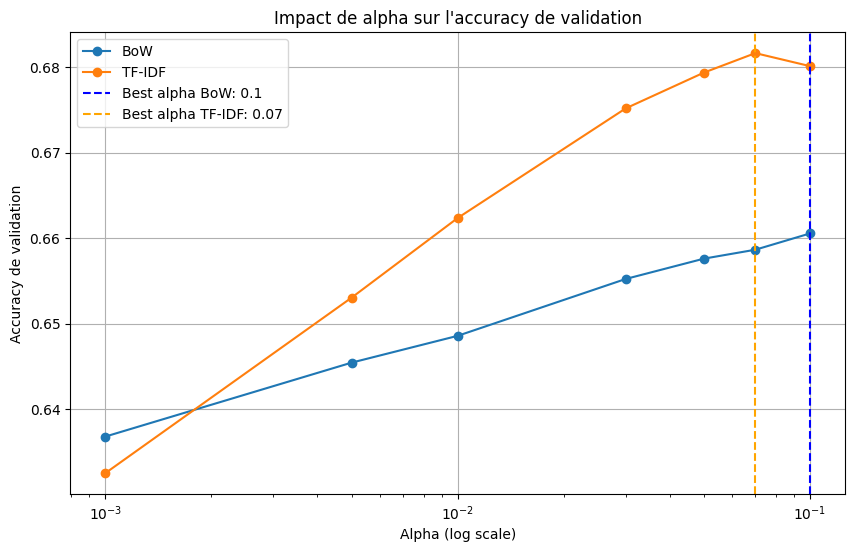

In [31]:
# A.1.1 — Votre code ici
# On trace une courbe montrant l'accuracy de validation en fonction d'alpha (en abscisse log) pour les deux variantes BoW et TF-IDF sur le même graphique
plt.figure(figsize=(10, 6))
plt.plot(df_results['alpha'], df_results['acc_bow'], marker='o', label='BoW')
plt.plot(df_results['alpha'], df_results['acc_tfidf'], marker='o', label='TF-IDF')
# On ajoute une lignes verticale pointillé indiquant la meilleur alpha retenu pour chaque variante
plt.axvline(x=best_alpha_bow, color='blue', linestyle='--', label=f'Best alpha BoW: {best_alpha_bow}')
plt.axvline(x=best_alpha_tfidf, color='orange', linestyle='--', label=f'Best alpha TF-IDF: {best_alpha_tfidf}')

plt.xscale('log')
plt.xlabel('Alpha (log scale)')
plt.ylabel('Accuracy de validation')
plt.title('Impact de alpha sur l\'accuracy de validation')
plt.legend()
plt.grid(True)
plt.show()

## A.2 — Entraînement des modèles Naive Bayes

**Ce que vous devez faire :**

En utilisant les meilleurs alphas trouvés à l'étape précédente (`best_alpha_bow`, `best_alpha_tfidf`) :

1. Instancier deux modèles `MultinomialNB` :
   - `nb_model_bow` avec `alpha=best_alpha_bow`
   - `nb_model_tfidf` avec `alpha=best_alpha_tfidf`
2. Entraîner chaque modèle sur l'ensemble d'entraînement correspondant (`.fit(X_train_..., y_train)`)

> ⚠️ On entraîne **uniquement sur `X_train`**, jamais sur val ou test.


In [32]:
# A.2 — Votre code ici
# 1. Instancier les deux modèles MultinominalNB
nb_model_bow = MultinomialNB(alpha=best_alpha_bow)
nb_model_tfidf = MultinomialNB(alpha=best_alpha_tfidf)
# 2. On entraine les modèles sur l'ensemble d'entrainement correspondant
nb_model_bow.fit(X_train_bow, y_train)
nb_model_tfidf.fit(X_train_tfidf, y_train)

,alpha,np.float64(0.07)
,force_alpha,True
,fit_prior,True
,class_prior,None


In [33]:
# On enregistre les modèles entrainés pour une utilisation ultérieure

# sauvegarde du modèle BoW
with open('nb_model_bow.pkl', 'wb') as f:
    pickle.dump(nb_model_bow, f)
# sauvegarde du modèle TF-IDF
with open('nb_model_tfidf.pkl', 'wb') as f:
    pickle.dump(nb_model_tfidf, f)

## A.3 — Prédictions sur le test

**Ce que vous devez faire :**

Générer les prédictions des deux modèles sur `X_test_bow` et `X_test_tfidf` avec `.predict(...)`.

Stocker les résultats dans :
- `nb_predictions_bow`
- `nb_predictions_tfidf`


In [34]:
# A.3 — Votre code ici
nb_predictions_bow = nb_model_bow.predict(X_test_bow)
nb_predictions_tfidf = nb_model_tfidf.predict(X_test_tfidf)

## A.4 — Évaluation quantitative

Le but de cette section est d'analyser les performances des modèles afin de récupérer le meilleur.

**Ce que vous devez faire :**

Pour chaque variante (BoW et TF-IDF), calculer et afficher les métriques suivantes :

| Métrique | Fonction sklearn | Ce qu'elle mesure |
|---|---|---|
| **Accuracy** | `accuracy_score` | Proportion de prédictions correctes |
| **MSE** | `mean_squared_error` | Erreur quadratique moyenne (sur labels encodés) |
| **R²** | `r2_score` | Coefficient de détermination |
| **Classification report** | `classification_report` | Précision, rappel, F1-score par classe |
| **Matrice de confusion** | `ConfusionMatrixDisplay` | Visualisation des erreurs par classe |  


> 💡 Pour MSE et R², les labels textuels doivent d'abord être encodés en entiers avec `LabelEncoder` de `sklearn.preprocessing`. Faites un `.fit` sur `y_train` uniquement, puis `.transform` sur `y_test` et les prédictions.

> 💡 Pensez à tracer la matrice de confusion avec `ConfusionMatrixDisplay.from_predictions(...)` et à faire pivoter les étiquettes en abscisse pour la lisibilité (`plt.xticks(rotation=45, ha='right')`).


### A.4.1 — Performances de BoW

Accuracy sur le test (BoW) : 0.6666
MSE sur le test (BoW) : 3.0897
R2 sur le test (BoW) : 0.0296
Classification Report (BoW) :
                      precision    recall  f1-score   support

             Anxiety       0.68      0.73      0.71       767
             Bipolar       0.60      0.76      0.68       556
          Depression       0.57      0.61      0.59      3076
              Normal       0.92      0.70      0.80      3268
Personality disorder       0.50      0.56      0.53       215
              Stress       0.52      0.43      0.47       516
            Suicidal       0.60      0.72      0.65      2129

            accuracy                           0.67     10527
           macro avg       0.63      0.65      0.63     10527
        weighted avg       0.69      0.67      0.67     10527

Matrice de confusion (BoW) :


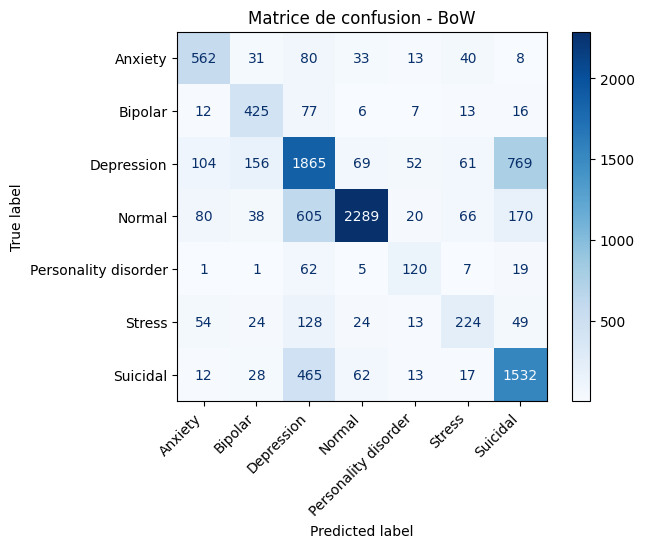

In [35]:
# A.4.1 — Votre code ici
# Accuracy
accuracy_bow_test = accuracy_score(y_test, nb_predictions_bow)
# MSE
# On doit d'abord convertir les labels en numériques pour calculer le MSE
labelEncoder = LabelEncoder()
labelEncoder.fit(y_train)
y_test_encoded = labelEncoder.transform(y_test)
nb_predictions_bow_encoded = labelEncoder.transform(nb_predictions_bow)
# R2
r2_bow_test = r2_score(y_test_encoded, nb_predictions_bow_encoded)
# Classification report
classification_report_bow = classification_report(y_test, nb_predictions_bow)
# Matrice de confusion
confusion_matrix_bow = confusion_matrix(y_test, nb_predictions_bow)

print(f"Accuracy sur le test (BoW) : {accuracy_bow_test:.4f}")
print(f"MSE sur le test (BoW) : {np.mean((y_test_encoded - nb_predictions_bow_encoded) ** 2):.4f}")
print(f"R2 sur le test (BoW) : {r2_bow_test:.4f}")
print("Classification Report (BoW) :")
print(classification_report_bow)

print("Matrice de confusion (BoW) :")
disp_bow = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_bow, display_labels=labelEncoder.classes_)
disp_bow.plot(cmap=plt.cm.Blues)
plt.xticks(rotation=45, ha='right')
plt.title("Matrice de confusion - BoW")
plt.show()

### A.4.2 — Performances de TF-IDF

Accuracy sur le test (TF-IDF) : 0.6928
MSE sur le test (TF-IDF) : 2.8379
R2 sur le test (TF-IDF) : 0.1087
Classification Report (TF-IDF) :
                      precision    recall  f1-score   support

             Anxiety       0.75      0.70      0.73       767
             Bipolar       0.82      0.57      0.67       556
          Depression       0.54      0.76      0.63      3076
              Normal       0.89      0.81      0.85      3268
Personality disorder       1.00      0.25      0.40       215
              Stress       0.85      0.24      0.37       516
            Suicidal       0.66      0.60      0.63      2129

            accuracy                           0.69     10527
           macro avg       0.79      0.56      0.61     10527
        weighted avg       0.73      0.69      0.69     10527

Matrice de confusion (TF-IDF) :


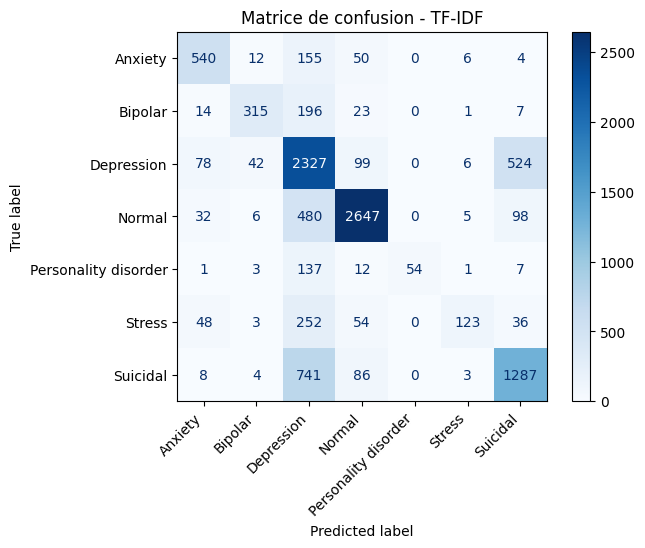

In [36]:
# A.4.2 — Votre code ici
# Accuracy
accuracy_tfidf_test = accuracy_score(y_test, nb_predictions_tfidf)
# MSE
# On doit d'abord convertir les labels en numériques pour calculer le MSE
labelEncoder = LabelEncoder()
labelEncoder.fit(y_train)
y_test_encoded = labelEncoder.transform(y_test)
nb_predictions_tfidf_encoded = labelEncoder.transform(nb_predictions_tfidf)
# R2
r2_tfidf_test = r2_score(y_test_encoded, nb_predictions_tfidf_encoded)
# Classification report
classification_report_tfidf = classification_report(y_test, nb_predictions_tfidf)
# Matrice de confusion
confusion_matrix_tfidf = confusion_matrix(y_test, nb_predictions_tfidf)

print(f"Accuracy sur le test (TF-IDF) : {accuracy_tfidf_test:.4f}")
print(f"MSE sur le test (TF-IDF) : {np.mean((y_test_encoded - nb_predictions_tfidf_encoded) ** 2):.4f}")
print(f"R2 sur le test (TF-IDF) : {r2_tfidf_test:.4f}")
print("Classification Report (TF-IDF) :")
print(classification_report_tfidf)

print("Matrice de confusion (TF-IDF) :")
disp_tfidf = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix_tfidf, display_labels=labelEncoder.classes_)
disp_tfidf.plot(cmap=plt.cm.Blues)
plt.xticks(rotation=45, ha='right')
plt.title("Matrice de confusion - TF-IDF")
plt.show()

## Que choisir ?

Si on se fit à l'accuracy globale, on remaque que TF-IDF gagne, mais il faut analyser dans les détails, c'est ainsi qu'on peut déterminer que **BoW reste meilleur sur les classes critiques**.  

| Classe | BoW recall | TF-IDF recall | Gagnant |
|-|-|-|-|
| Anxiety              | 73% | 70% | BoW    |
| Bipolar              | 76% | 57% | BoW    |
| Depression           | 61% | 77% | TF-IDF |
| Normal               | 70% | 79% | TF-IDF |
| Personality disorder | 56% | 21% | BoW    |
| Stress               | 43% | 25% | BoW    |
| Suicidal             | 72% | 60% | BoW    |

TF-IDF est meilleur sur les deux classes **les plus représentées** (*Normal* et *Depression*), ce qui tire son accuracy globale vers le haut. Mais sur les 5 autres classes, BoW gagne à chaque fois, parfois très largement comme *Stress* (43% vs 25%) ou *Bipolar* (76% vs 57%)

**Pourquoi ce phénomène ?**  

TF-IDF prénalise les mots fréquents. C'est utile pour séparer *Normal* de *Depression*, mais pour les classes rares comme *Stress* ou *Personality disorder*, **leus mots caractéristiques sont précisément des mots fréquents** dans le corpus global (*overwhelmed*, *pressure*, *relationship*...).  
TF-IDF les "dépouille" de leur signal, et le modèle les classe massivement en *Depression* faute d'indices.  
Le cas *Personality disorder* avec TF-IDF est particulièrement frappant: **précision 0.98 mais recall 0.21** — le modèle est très sûr de lui quand il prédit cette classe, mais il rate 79% des vrais cas.




## A.5 — Déploiement sur le dataset principal (`train.csv`)

C'est l'étape finale de la partie supervisée. Le meilleur modèle (BoW ou TF-IDF, selon vos résultats) est utilisé pour **annoter automatiquement** le dataset principal `train.csv`, qui sera transmis au Groupe 2.

**Ce que vous devez faire :**

1. Identifier lequel de `nb_model_bow` ou `nb_model_tfidf` obtient la meilleure accuracy sur le test
2. Charger `train.csv` (disponible dans `../../data/train.csv`) dans un DataFrame `df_main`
3. Appliquer la même chaîne de prétraitement que sur `combined_data.csv` :
   - Nettoyage (`cleaner`)
   - Tokenisation (`simple_tokenizer`)
   - Vectorisation avec le **vectoriseur déjà fitté** sur le train (`bow_vectorizer.transform(...)` ou `tfidf_vectorizer.transform(...)`) — **ne pas refaire de `.fit`**
4. Générer les prédictions avec le meilleur modèle et les stocker dans une colonne `predicted_sentiment`
5. Afficher les 10 premières lignes avec la colonne de prédiction
6. Sauvegarder le DataFrame annoté dans un fichier CSV : `train_with_sentiments.csv`

> ⚠️ Variable nommée `x_full_tfidf` (disponible depuis la partie commune) si vous souhaitez éviter de recalculer la vectorisation sur tout le corpus.

> 💡 La distribution des sentiments prédits doit ressembler approximativement à celle observée sur `combined_data.csv`. Si une classe domine massivement, cela peut indiquer un problème dans le pipeline.


In [37]:
# On charge les modèles pour la suite de l'analyse
with open('nb_model_bow.pkl', 'rb') as f:
    nb_model_bow = pickle.load(f)
with open('nb_model_tfidf.pkl', 'rb') as f:
    nb_model_tfidf = pickle.load(f)

In [38]:
# On charge le dataset initial train.csv pour l'analyse finale sur l'ensemble complet
df_main = pd.read_csv("../../data/train.csv")
print(f"Dataset chargé : {df_main.shape[0]} lignes")

# Pré-traitement du dataset complet
df_main['statement_clean'] = df_main['Context'].apply(cleaner)
# Tokenisation du dataset complet
df_main_tokens = df_main['statement_clean'].apply(simple_tokenizer)
df_main_text   = df_main_tokens.apply(lambda t: ' '.join(t))
# Vectorisation du dataset complet avec les vectoriseur déjà filtrés
X_main_bow = bow_vectorizer.transform(df_main_text)
# Prédiction avec BoW
df_main['predicted_sentiment_bow'] = nb_model_bow.predict(X_main_bow)
# Aperçu avec la colonne de prédiction BoW
print(df_main[['Context', 'predicted_sentiment_bow']].head())
# Distribution des sentiments prédits par BoW
print("\nDistribution BoW :")
print(df_main['predicted_sentiment_bow'].value_counts())

Dataset chargé : 3512 lignes
                                             Context predicted_sentiment_bow
0  I'm going through some things with my feelings...                Suicidal
1  I'm going through some things with my feelings...                Suicidal
2  I'm going through some things with my feelings...                Suicidal
3  I'm going through some things with my feelings...                Suicidal
4  I'm going through some things with my feelings...                Suicidal

Distribution BoW :
predicted_sentiment_bow
Depression              2044
Suicidal                 480
Stress                   336
Anxiety                  245
Bipolar                  164
Normal                   142
Personality disorder     101
Name: count, dtype: int64


In [39]:
# Sauvegarde du nouveau dataset avec les sentiments prédits
df_main.to_csv("train_with_sentiments.csv", index=False)
print("\nFichier sauvegardé : train_with_sentiments.csv")


Fichier sauvegardé : train_with_sentiments.csv


Le problème principal que l'on a ici est le déséquilibre des classes, on remarque que dans notre dataset, *Depression* est en grande majorité, ce qui peut sembler logique à première vue mais pas forcément si on regarde d'un peu plus prés les matrices de confusion pour TF-IDF et Bow avec Naive Bayes.  
Le modèle a tendance à tout absorber dans *Depression* quand il hésite, notemment:
- Les vrais cas de *Stress* -> prédit *Dépression*
- Les vrais cas de *Suicidal* → prédit *Depression*
- Les vrais cas de *Bipolar* → prédit *Depression*

Donc une partie de ces 2044 "*Depression*" sont en réalité d'autre sentiments mal classifiés.

Pour essayer d'avoir de meilleur performances, on va essayer d'appliquer une nouvelle stratégie en utilisant **LogisticRegression avec TF-IDF**.


---
## LR — Version extra performante — LogisticRegression + TF-IDF

### Tout d'abord, qu'est-ce que la Régression Logistique ?

La Régression Logistique répond à la question : **"Étant donné ce vecteur TF-IDF, à quelle classe ce texte appartient-il le plus probablement ?"**

> Sympatique vidéo résumant le principe : https://www.youtube.com/watch?v=3bvM3NyMiE0

Contrairement à Naive Bayes qui calcule des probabilités indépendamment mot par mot, la Régression Logistique **apprend un poids pour chaque feature** (ici chaque n-gram TF-IDF), et combine ces poids pour produire un score par classe.

#### Pourquoi est-elle meilleure que Naive Bayes ici ?

| | Naive Bayes | Logistic Regression |
|-|-|-|
| Hypothèse | Mots indépendants | Aucune hypothèse sur les features |
| Frontière | Probabiliste naïve | Frontière de décision optimisée |
| Classes déséquilibrées | Biais vers les classes majoritaires | Gère mieux avec `class_weight='balanced'` |
| Corrélations entre mots | Ignorées | Prises en compte implicitement |

Le paramètre clé est **`C`** (inverse de la régularisation) :
- `C` petit → forte régularisation, modèle simple, évite l'overfitting
- `C` grand → faible régularisation, modèle plus complexe, peut overfit

Le paramètre `class_weight='balanced'` est crucial ici : il compense automatiquement le déséquilibre entre *Depression* (sur-représentée) et *Stress* ou *Personality disorder* (sous-représentées).



--- 

### LR.1 — Tuning du paramètre C sur la validation

Comme pour Naive Bayes avec alpha, on cherche ici la meilleur valeur du paramètre `C` sur la validation (<u>jamais sur le test !</u>).  

> Temps d'exécution ~ 2min

In [40]:
from sklearn.linear_model import LogisticRegression

C_values = [0.01, 0.05, 0.1, 0.3, 0.5, 1.0, 3.0, 5.0, 10.0]
lr_results = {'C': [], 'acc_val': []}

for C in C_values:
    # Ancienne version sans régularisation L1
    lr = LogisticRegression(
        C=C,
        max_iter=1000,
        class_weight='balanced',
        solver='lbfgs',
        random_state=42
    )
    # Version avec régularisation L1 (sparse data) — à tester pour voir si ça améliore les résultats
    # lr = LogisticRegression(
    #     C=C,
    #     penalty='l1',
    #     solver='saga',
    #     max_iter=5000,
    #     tol=1e-2,
    #     class_weight='balanced',
    #     random_state=42
    # )
    lr.fit(X_train_tfidf, y_train)
    y_pred_val = lr.predict(X_val_tfidf)
    acc = accuracy_score(y_val, y_pred_val)
    lr_results['C'].append(C)
    lr_results['acc_val'].append(acc)
    print(f"C={C:.3f} → acc_val={acc:.4f}")

df_lr_results = pd.DataFrame(lr_results)
best_C = df_lr_results.loc[df_lr_results['acc_val'].idxmax(), 'C']
print(f"\nMeilleur C : {best_C} avec accuracy de validation : {df_lr_results['acc_val'].max():.4f}")

C=0.010 → acc_val=0.6492
C=0.050 → acc_val=0.6843
C=0.100 → acc_val=0.7013
C=0.300 → acc_val=0.7209
C=0.500 → acc_val=0.7295
C=1.000 → acc_val=0.7390
C=3.000 → acc_val=0.7457
C=5.000 → acc_val=0.7453
C=10.000 → acc_val=0.7441

Meilleur C : 3.0 avec accuracy de validation : 0.7457


### LR.2 — Courbe de validation

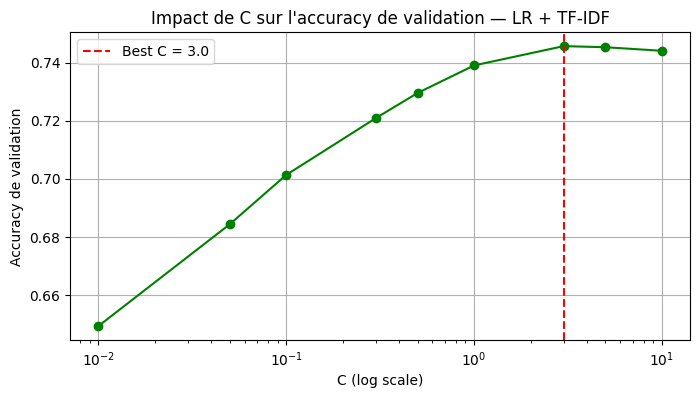

In [41]:
plt.figure(figsize=(8, 4))
plt.semilogx(df_lr_results['C'], df_lr_results['acc_val'], marker='o', color='green')
plt.axvline(x=best_C, color='red', linestyle='--', label=f'Best C = {best_C}')
plt.xlabel('C (log scale)')
plt.ylabel('Accuracy de validation')
plt.title('Impact de C sur l\'accuracy de validation — LR + TF-IDF')
plt.legend()
plt.grid(True)
plt.show()

### LR.3 — Entraînement du modèle final

On réentraine **une seul fois** avec `best_C` trouvé à l'étape précédente.  
Les autres paramètre important:
- `max_iter=1000` — LR est un **algorithme itératif**, il a besoin de suffisament d'itérations pour converger avec 50k features.
- `class_wieght='balanced'` — le plus important, il dit au modèle "*compense automatiquement le déséquilibre entre classes*". Concrètement, les exemples des classes rares (*Stress*, *Personality disorder*) vont compter beaucoup plus dans le calcul de l'erreur, ce qui force le modèle à ne plus tout absorber dans *Depression*.
- `solver='lbfgs'` — l'algorithme d'optimisation utilisé pour trouver les poids. C'est le plus recommandé pour du multi-classes avec beaucoup de features.
- `random_state=42` — Comme tout les autre modèles, cette option représente la graine, ce qui permet de reproduire le même résultat constamment.

> `multi_class=multinominal` est définit initialement, il dit au modèle de considérer toutes les classes simultanément plutôt que de faire du "*one-vs-rest*" (7 classifieurs binaires séparés)

> On oublie pas à la fin de sauvegarder le modèle en `.plk` comme pour les modèles Naive Bayes.

In [42]:
lr_model_tfidf = LogisticRegression(
        C=C,
        max_iter=1000,
        class_weight='balanced',
        solver='lbfgs',
        random_state=42
    )
# lr_model_tfidf = LogisticRegression(
#     C=best_C,
#     penalty='l1',
#     solver='saga',
#     max_iter=2000,
#     class_weight='balanced',
#     random_state=42
# )
lr_model_tfidf.fit(X_train_tfidf, y_train)

# Sauvegarde
with open('lr_model_tfidf.pkl', 'wb') as f:
    pickle.dump(lr_model_tfidf, f)

print("Modèle LogisticRegression entraîné et sauvegardé.")

Modèle LogisticRegression entraîné et sauvegardé.


### LR.4 — Prédiction et évaluation  

Même structure que pour [A.4](#a4--évaluation-quantitative), on prédit sur `X_test_tfidf` puis on calcule l'accuracy, le MSE, le R², le classification report et la matrice de confusion.  
Le point clé ici est de **regarder le recall par classe** dans le classification report — c'est là que l'on verra si `classe_weight='balanced'` a vraiment aidé *Stress* et *Personality disorder* par rapport aux résultats Naive Bayes.

Accuracy (LR + TF-IDF) : 0.7532
MSE : 2.7247
R² : 0.1443

Classification Report :
                      precision    recall  f1-score   support

             Anxiety       0.77      0.82      0.80       767
             Bipolar       0.82      0.76      0.79       556
          Depression       0.71      0.67      0.69      3076
              Normal       0.88      0.92      0.90      3268
Personality disorder       0.70      0.62      0.66       215
              Stress       0.57      0.57      0.57       516
            Suicidal       0.63      0.65      0.64      2129

            accuracy                           0.75     10527
           macro avg       0.73      0.72      0.72     10527
        weighted avg       0.75      0.75      0.75     10527



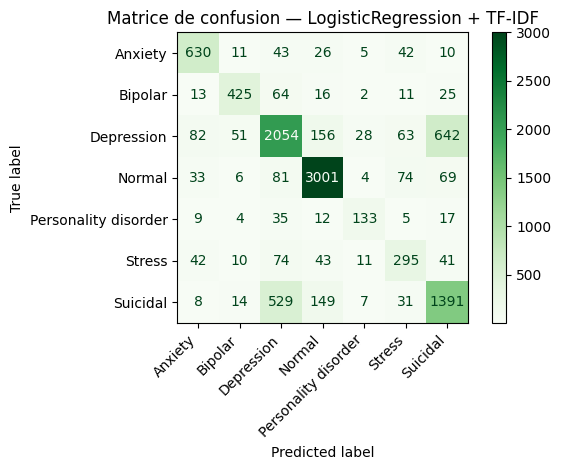

In [48]:
lr_predictions_tfidf = lr_model_tfidf.predict(X_test_tfidf)

# Métriques
accuracy_lr = accuracy_score(y_test, lr_predictions_tfidf)
labelEncoder_lr = LabelEncoder()
labelEncoder_lr.fit(y_train)
y_test_enc = labelEncoder_lr.transform(y_test)
lr_pred_enc = labelEncoder_lr.transform(lr_predictions_tfidf)
r2_lr = r2_score(y_test_enc, lr_pred_enc)
mse_lr = mean_squared_error(y_test_enc, lr_pred_enc)

print(f"Accuracy (LR + TF-IDF) : {accuracy_lr:.4f}")
print(f"MSE : {mse_lr:.4f}")
print(f"R² : {r2_lr:.4f}")
print("\nClassification Report :")
print(classification_report(y_test, lr_predictions_tfidf))

# Matrice de confusion
disp_lr = ConfusionMatrixDisplay.from_predictions(
    y_test, lr_predictions_tfidf,
    display_labels=lr_model_tfidf.classes_,
    cmap=plt.cm.Greens
)
plt.xticks(rotation=45, ha='right')
plt.title("Matrice de confusion — LogisticRegression + TF-IDF")
plt.tight_layout()
plt.show()

### LR.5 — Comparaison des 3 modèles

In [44]:
comparison = pd.DataFrame({
    'Modèle': ['Naive Bayes BoW', 'Naive Bayes TF-IDF', 'LogisticRegression TF-IDF'],
    'Accuracy': [accuracy_bow_test, accuracy_tfidf_test, accuracy_lr],
    'R²': [r2_bow_test, r2_tfidf_test, r2_lr]
})
comparison = comparison.sort_values('Accuracy', ascending=False).reset_index(drop=True)
print(comparison)

                      Modèle  Accuracy        R²
0  LogisticRegression TF-IDF  0.753206  0.144263
1         Naive Bayes TF-IDF  0.692790  0.108700
2            Naive Bayes BoW  0.666572  0.029639


#### Que peut-on remarquer ?

##### Avant amélioration

Si l'on compare les résultats obtenues par rapport à Naive Bayes avec TF-IDF:

| Classe | NB TF-IDF recall | LR TF-IDF recall | Évolution |
|-|-|-|-|
| Anxiety              | 70% | 82% | +12% |
| Bipolar              | 57% | 76% | +19% |
| Depression           | 77% | 67% | **\-10%** |
| Normal               | 79% | 92% | +13% |
| Personality disorder | 21% | 62% | **+41%** |
| Stress               | 25% | 57% | **+32%** |
| Suicidal             | 60% | 65% | +5% |  

On remarque nettement une grande amélioration, **mais il reste de gros progrès à faire**:
- Suicidal est le gros problème, sur la matrice de confusion on remarque que sur 2129 vrais cas *Suicidal*, 1391 sont correctement classés **mais 529 sont prédit *Depression***. C'est le problème le plus grave car c'est une classe à risque critique dans le contexte médical (confondre *Suicidal* avec *Depression* peut avoir des conséquences réelles...)
- ***Depression* a aussi un recall faible (0.67)**: 642 vrais *Depression* sont prédits *Suicidal*, et 156 *Normal*. Ces deux classes sont sémantiquement très proches dans le corpus.
- Le **R² de 0.144 est bas, mais c'est attendu et normal** — R² est une mértique de régression, elle n'a pas grand sens sur un problème de classification multi-classes avec des labels ordonnées arbitrairement. **Ce n'est pas un indicateur fiable ici**. 


##### Après amélioration

Pour améliorer les résultats, on ajoute `solver='saga'` avec `penalty='l1'`. L1 fait de la sélection de features implicite, ce qui peut mieux séparer des classes sémantiquement proches comme *Depression* et *Suicidal*:
```java
lr_model_l1 = LogisticRegression(
    C=best_C,
    penalty='l1',
    solver='saga',
    max_iter=2000,
    class_weight='balanced',
    multi_class='multinomial',
    random_state=42
)
```
Le problème étant le temps d'exécution... qui peut très facilement atteindre les **4 heures**.
Il faut donc trouver le temps pour tester cette technique.

### LR.6 — Déploiement sur le dataset principal (`train.csv`)

In [45]:
# On charge les modèles pour la suite de l'analyse
with open('lr_model_tfidf.pkl', 'rb') as f:
    lr_model_tfidf = pickle.load(f)

In [46]:
# On charge le dataset initial train.csv pour l'analyse finale sur l'ensemble complet
df_main = pd.read_csv("../../data/train.csv")
print(f"Dataset chargé : {df_main.shape[0]} lignes")

# Pré-traitement du dataset complet
df_main['statement_clean'] = df_main['Context'].apply(cleaner)
# Tokenisation du dataset complet
df_main_tokens = df_main['statement_clean'].apply(simple_tokenizer)
df_main_text   = df_main_tokens.apply(lambda t: ' '.join(t))
# Vectorisation du dataset complet avec les vectoriseur déjà filtrés
X_main_tfidf = tfidf_vectorizer.transform(df_main_text)
# Prédiction avec TF-IDF
df_main['predicted_sentiment_tfidf'] = lr_model_tfidf.predict(X_main_tfidf)
# Aperçu avec la colonne de prédiction TF-IDF
print(df_main[['Context', 'predicted_sentiment_tfidf']].head())
# Distribution des sentiments prédits par TF-IDF
print("\nDistribution TF-IDF :")
print(df_main['predicted_sentiment_tfidf'].value_counts())

Dataset chargé : 3512 lignes
                                             Context predicted_sentiment_tfidf
0  I'm going through some things with my feelings...                Depression
1  I'm going through some things with my feelings...                Depression
2  I'm going through some things with my feelings...                Depression
3  I'm going through some things with my feelings...                Depression
4  I'm going through some things with my feelings...                Depression

Distribution TF-IDF :
predicted_sentiment_tfidf
Normal                  1244
Depression               960
Stress                   703
Suicidal                 259
Anxiety                  238
Bipolar                   58
Personality disorder      50
Name: count, dtype: int64


In [47]:
# Sauvegarde du nouveau dataset avec les sentiments prédits
df_main.to_csv("train_with_sentiments.csv", index=False)
print("\nFichier sauvegardé : train_with_sentiments.csv")


Fichier sauvegardé : train_with_sentiments.csv


---

# 📋 Récapitulatif et transmission au Groupe 2

Une fois les deux parties terminées, mettre en commun les résultats :

| Étape | Groupe supervisé | Groupe non-supervisé |
|---|---|---|
| Meilleure accuracy (test) | ? | ? |
| Modèle retenu | Naive Bayes BoW ou TF-IDF | K-Means TF-IDF ou BoW |
| Fichier produit | `train_with_sentiments.csv` | `train_with_sentiments_kmeans.csv` |

**Décision finale** : le modèle avec la meilleure accuracy (ou justifiée par d'autres critères) est sélectionné pour fournir les annotations au Groupe 2.

Le fichier `train_with_sentiments.csv` (ou `_kmeans`) contenant la colonne `predicted_sentiment` est transmis au Groupe 2 pour le filtrage par sentiments dans le système Q&A.
